In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score,confusion_matrix,precision_score, recall_score,roc_auc_score,precision_recall_curve,balanced_accuracy_score
import optuna
import glob
import os

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-28-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/03-01-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-16-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-15-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-21-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/03-02-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-22-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-14-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-23-2018.csv
/kaggle/input/datasets/mominulhoque/cicids2018-m/02-20-2018/02-20-2018.csv


In [4]:
selected_files = [
    "/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-14-2018.csv",
    "/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-15-2018.csv",
    "/kaggle/input/datasets/mominulhoque/cicids2018-m/CICIDS2018/02-16-2018.csv"
]

df_list = [pd.read_csv(f, low_memory=False) for f in selected_files]
combined_df = pd.concat(df_list, ignore_index=True)

In [5]:
combined_df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320859.5,139.300036,56320958,56320761,Benign
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56320733.0,114.551299,56320814,56320652,Benign
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,0.0,0.0,0,0,56319311.5,301.934596,56319525,56319098,Benign
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [6]:
combined_df.shape

(3145725, 80)

In [7]:
combined_df['Label'].value_counts()

Label
Benign                      2110475
DoS attacks-Hulk             461912
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
Label                             1
Name: count, dtype: int64

In [8]:
combined_df.isnull().sum()

Dst Port         0
Protocol         0
Timestamp        0
Flow Duration    0
Tot Fwd Pkts     0
                ..
Idle Mean        0
Idle Std         0
Idle Max         0
Idle Min         0
Label            0
Length: 80, dtype: int64

In [9]:
col=combined_df.columns
col

Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
      

In [10]:
combined_df=combined_df.drop(columns='Timestamp')

In [11]:
zero_variance_cols = [col for col in combined_df.columns if combined_df[col].nunique() <= 1]
zero_variance_cols

[]

In [12]:
inf_nan_cols = combined_df.columns[
    (combined_df.isin([np.inf, -np.inf]).any(axis=0)) | (combined_df.isna().any(axis=0))
]

print(inf_nan_cols)

Index(['Flow Byts/s', 'Flow Pkts/s'], dtype='object')


In [13]:
combined_df['Flow Byts/s'] = combined_df['Flow Byts/s'].replace([np.inf, -np.inf], np.nan)
combined_df['Flow Pkts/s'] = combined_df['Flow Pkts/s'].replace([np.inf, -np.inf], np.nan)

In [14]:
combined_df['Flow Byts/s'] = combined_df['Flow Byts/s'].fillna(0)
combined_df['Flow Pkts/s'] = combined_df['Flow Pkts/s'].fillna(0)

In [15]:
inf_nan_cols = combined_df.columns[
    (combined_df.isin([np.inf, -np.inf]).any(axis=0)) | (combined_df.isna().any(axis=0))
]

print(inf_nan_cols)

Index([], dtype='object')


In [16]:
# Remove rows where Label == 'Label'
combined_df = combined_df[combined_df['Label'] != 'Label']

# Verify
print(combined_df['Label'].value_counts())

Label
Benign                      2110475
DoS attacks-Hulk             461912
FTP-BruteForce               193360
SSH-Bruteforce               187589
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
Name: count, dtype: int64


In [17]:

le = LabelEncoder()

combined_df['Label'] = le.fit_transform(combined_df['Label'])

In [18]:
combined_df['Label'].value_counts()

Label
0    2110475
2     461912
5     193360
6     187589
3     139890
1      41508
4      10990
Name: count, dtype: int64

In [19]:
X = combined_df.drop('Label', axis=1)
y = combined_df['Label']

In [20]:
print(X.shape,y.shape)

(3145724, 78) (3145724,)


In [21]:
y.value_counts()

Label
0    2110475
2     461912
5     193360
6     187589
3     139890
1      41508
4      10990
Name: count, dtype: int64

In [22]:
# First split: Train (70%) and Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [23]:
print(X_train.shape,X_temp.shape,y_train.shape,y_temp.shape)

(2202006, 78) (943718, 78) (2202006,) (943718,)


In [24]:
# Second split: Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

In [25]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [27]:
from sklearn.utils import resample

# 1. Create a smaller sample for tuning
X_sample, y_sample = resample(
    X_train, y_train,
    n_samples=200000,   
    random_state=42,
    stratify=y_train
)

In [28]:
def objective(trial):

    C = trial.suggest_float("C", 1e-4, 10, log=True)
    max_iter = trial.suggest_int("max_iter", 200, 800)
    tol = trial.suggest_float("tol", 1e-4, 1e-2, log=True)

    model = LogisticRegression(
        C=C,
        solver="saga",         
        max_iter=max_iter,
        tol=tol,
        n_jobs=-1,
        class_weight="balanced"  
    )

    model.fit(X_sample, y_sample)

    y_pred = model.predict(X_val)

    score = f1_score(y_val, y_pred, average="weighted")

    return score

In [29]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner()
)

[I 2026-04-10 17:31:51,872] A new study created in memory with name: no-name-daa2ff0f-3cc4-4918-92d9-d9ec897c6f45


In [30]:
print("Starting Optuna optimization ...")
study.optimize(objective, n_trials=20, n_jobs=-1, show_progress_bar=True)

print("Best parameters:", study.best_params)
print("Best score:", study.best_value)
# study = optuna.create_study(direction="maximize")
# study.optimize(objective, n_trials=20, show_progress_bar=True)

Starting Optuna optimization ...


  0%|          | 0/20 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-04-10 17:38:13,423] Trial 1 finished with value: 0.7545367410197966 and parameters: {'C': 0.11355467393738305, 'max_iter': 354, 'tol': 0.000795320312132747}. Best is trial 1 with value: 0.7545367410197966.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


...

[I 2026-04-10 18:04:00,575] Trial 15 finished with value: 0.8161179224191403 and parameters: {'C': 6.755662694468201, 'max_iter': 640, 'tol': 0.0005986694621214748}. Best is trial 13 with value: 0.8365621115881671.
[I 2026-04-10 18:08:01,354] Trial 18 finished with value: 0.779143767090414 and parameters: {'C': 6.989678015826266, 'max_iter': 621, 'tol': 0.001518019030086228}. Best is trial 13 with value: 0.8365621115881671.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-04-10 18:08:33,550] Trial 16 finished with value: 0.8349108499029605 and parameters: {'C': 1.5654773210817086, 'max_iter': 680, 'tol': 0.0007382674286345467}. Best is trial 13 with value: 0.8365621115881671.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[I 2026-04-10 18:10:04,934] Trial 17 finished with value: 0.8142610804840126 and parameters: {'C': 7.089015783113114, 'max_iter': 621, 'tol': 0.0007319127237879285}. Best is trial 13 with value: 0.8365621115881671.
[I 2026-04-10 18:10:10,530] Trial 19 finished with value: 0.7802467151596583 and parameters: {'C': 0.0009180403590359216, 'max_iter': 789, 'tol': 0.0014061951563536475}. Best is trial 13 with value: 0.8365621115881671.
Best parameters: {'C': 7.172285078853914, 'max_iter': 699, 'tol': 0.0006897965513695732}
Best score: 0.8365621115881671


In [31]:
print(f"Best f1_score: {study.best_trial.value:.4f}")
print(f"Best Parameters: {study.best_trial.params}")
best_params = study.best_trial.params

Best f1_score: 0.8366
Best Parameters: {'C': 7.172285078853914, 'max_iter': 699, 'tol': 0.0006897965513695732}


In [32]:
best_params = study.best_params

final_model = LogisticRegression(
    **best_params,
    solver="saga",
    n_jobs=-1,
    class_weight="balanced"
)

final_model.fit(X_train, y_train)

LogisticRegression(C=7.172285078853914, class_weight='balanced', max_iter=699,
                   n_jobs=-1, solver='saga', tol=0.0006897965513695732)

In [34]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

y_val_pred = final_model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_val_pred))

# Better metrics
print("F1 Score (Weighted):", f1_score(y_val, y_val_pred, average="weighted"))
print("F1 Score (Macro):", f1_score(y_val, y_val_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_pred))

Accuracy: 0.9439896240190396
F1 Score (Weighted): 0.9463817806305944
F1 Score (Macro): 0.7778470604631541

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    316571
           1       0.58      0.83      0.68      6226
           2       0.98      0.97      0.97     69287
           3       0.62      0.55      0.58     20984
           4       0.33      1.00      0.50      1648
           5       0.71      0.78      0.74     29004
           6       0.96      1.00      0.98     28139

    accuracy                           0.94    471859
   macro avg       0.74      0.87      0.78    471859
weighted avg       0.95      0.94      0.95    471859



In [37]:
y_test_pred = final_model.predict(X_test)


--- Evaluation: Logistic Regression on Test Data ---
Accuracy: 0.9435
F1 Score (Weighted): 0.9460
F1 Score (Macro): 0.7754

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    316572
           1       0.58      0.83      0.68      6226
           2       0.98      0.97      0.97     69287
           3       0.62      0.55      0.58     20983
           4       0.32      0.99      0.49      1649
           5       0.70      0.78      0.74     29004
           6       0.96      1.00      0.98     28138

    accuracy                           0.94    471859
   macro avg       0.74      0.87      0.78    471859
weighted avg       0.95      0.94      0.95    471859



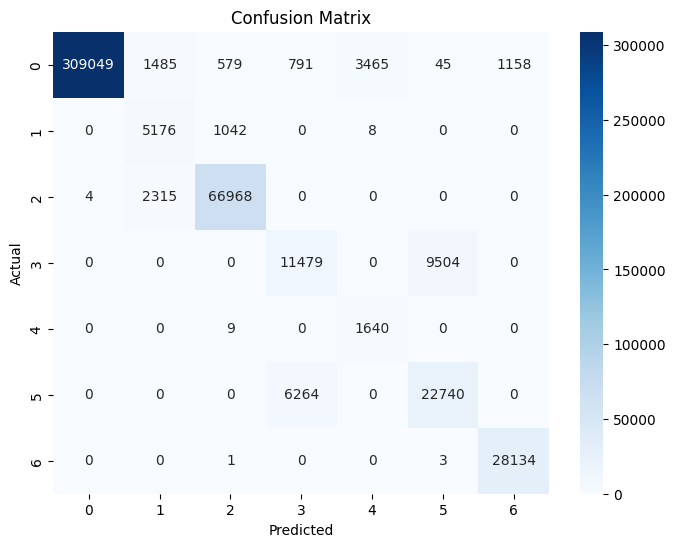


ROC-AUC (OvR): 0.9931


In [39]:
print("\n--- Evaluation: Logistic Regression on Test Data ---")

# Predictions
y_test_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)

# Accuracy & F1
acc = accuracy_score(y_test, y_test_pred)
f1_weighted = f1_score(y_test, y_test_pred, average="weighted")
f1_macro = f1_score(y_test, y_test_pred, average="macro")

print(f"Accuracy: {acc:.4f}")
print(f"F1 Score (Weighted): {f1_weighted:.4f}")
print(f"F1 Score (Macro): {f1_macro:.4f}")

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ Multiclass ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
print(f"\nROC-AUC (OvR): {roc_auc:.4f}")

In [41]:
from sklearn.model_selection import cross_val_predict

lr_oof_probs = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=3,
    method='predict_proba',
    n_jobs=-1
)

In [42]:
lr_oof_probs

array([[3.27027361e-04, 2.22948258e-02, 5.61715015e-03, ...,
        9.70377036e-02, 1.49280794e-01, 7.99958769e-03],
       [9.95603701e-01, 1.23534898e-03, 3.13521915e-03, ...,
        9.20207339e-07, 2.99536730e-06, 2.14515811e-05],
       [9.78315697e-01, 7.19649863e-04, 1.32126762e-03, ...,
        1.61457844e-03, 5.76436994e-03, 3.05161454e-03],
       ...,
       [4.44941641e-11, 3.04843952e-08, 2.53039362e-09, ...,
        4.28287476e-06, 8.77461590e-01, 8.77200439e-05],
       [9.42562258e-01, 2.84630478e-02, 2.82326967e-02, ...,
        1.31874377e-04, 9.92927184e-05, 4.61677180e-04],
       [9.99496177e-01, 4.95183512e-04, 2.10277197e-13, ...,
        8.42835434e-06, 1.27747259e-07, 4.84366741e-08]])

In [43]:
X_train_rf = np.column_stack((X_train, lr_oof_probs))
print(f"Old X_train shape: {X_train.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_train_rf.shape}")

Old X_train shape: (2202006, 78)
New X_train_rf shape (with LR prob feature): (2202006, 85)


In [45]:
lr_test_probs = final_model.predict_proba(X_test)

In [46]:
lr_test_probs

array([[9.87089976e-01, 3.72403488e-04, 7.86385619e-04, ...,
        7.03924835e-04, 3.89052462e-03, 1.75931924e-03],
       [1.35175892e-07, 3.50042812e-05, 5.14089859e-06, ...,
        9.56160719e-04, 5.24817096e-01, 1.13121616e-03],
       [7.90729881e-01, 2.07495716e-01, 4.32363968e-10, ...,
        1.75758219e-03, 7.10912981e-06, 7.21454977e-06],
       ...,
       [9.28752786e-01, 6.80871309e-02, 3.04075653e-03, ...,
        8.68777234e-05, 2.22234205e-05, 7.07375743e-06],
       [9.58883619e-01, 7.66039572e-06, 2.52770771e-04, ...,
        2.52298100e-04, 1.81313524e-04, 4.00045578e-02],
       [9.89815613e-01, 3.66507006e-04, 8.29486921e-04, ...,
        4.98226318e-04, 3.13188814e-03, 1.33761302e-03]])

In [47]:
X_test_rf = np.column_stack((X_test, lr_test_probs))

In [48]:
print(f"Old X_train shape: {X_test.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_test_rf.shape}")

Old X_train shape: (471859, 78)
New X_train_rf shape (with LR prob feature): (471859, 85)


In [50]:
lr_val_probs = final_model.predict_proba(X_val)

X_val_rf = np.column_stack((X_val, lr_val_probs))

In [51]:
print(f"Old X_train shape: {X_val.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_val_rf.shape}")

Old X_train shape: (471859, 78)
New X_train_rf shape (with LR prob feature): (471859, 85)


In [52]:
def objective_rf(trial):

    n_estimators = trial.suggest_int("n_estimators", 50, 200, step=50)
    max_depth = trial.suggest_int("max_depth", 5, 25)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 5)

    rf_tune = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",   
        random_state=42,
        n_jobs=-1
    )

    rf_tune.fit(X_train_rf, y_train)

    y_val_pred_rf = rf_tune.predict(X_val_rf)

    return f1_score(y_val, y_val_pred_rf, average="macro") 

In [55]:
study_rf = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner()
)

[I 2026-04-10 20:55:45,800] A new study created in memory with name: no-name-15aff1f3-1e86-4ebf-9364-e80855b209ba


In [56]:
print("\n--- Starting Optuna Optimization for Random Forest ---")
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)


--- Starting Optuna Optimization for Random Forest ---


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-10 21:01:03,603] Trial 0 finished with value: 0.9132049129879152 and parameters: {'n_estimators': 100, 'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.9132049129879152.
[I 2026-04-10 21:03:43,171] Trial 1 finished with value: 0.9162092147287283 and parameters: {'n_estimators': 50, 'max_depth': 14, 'min_samples_split': 3, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.9162092147287283.
[I 2026-04-10 21:06:09,820] Trial 2 finished with value: 0.9153641161159779 and parameters: {'n_estimators': 50, 'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 1}. Best is trial 1 with value: 0.9162092147287283.
[I 2026-04-10 21:10:50,795] Trial 3 finished with value: 0.915945299834083 and parameters: {'n_estimators': 100, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.9162092147287283.
[I 2026-04-10 21:13:15,114] Trial 4 finished with value: 0.9143201982585537 and parameters: {'n_

In [57]:
# 4. Output the best results
print(f"\nBest RF F1 Score: {study_rf.best_trial.value:.4f}")
print(f"Best RF Parameters: {study_rf.best_trial.params}")

# 5. Save the best parameters to use in our actual pipeline
best_rf_params = study_rf.best_trial.params


Best RF F1 Score: 0.9162
Best RF Parameters: {'n_estimators': 50, 'max_depth': 20, 'min_samples_split': 10, 'min_samples_leaf': 2}


In [58]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    **best_rf_params,
    class_weight="balanced",   
    n_jobs=-1,
    random_state=42
)

rf_final.fit(X_train_rf, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, min_samples_split=10,
                       n_estimators=50, n_jobs=-1, random_state=42)

In [59]:
y_val_rf_pred = rf_final.predict(X_val_rf)

print("Accuracy:", accuracy_score(y_val, y_val_rf_pred))


print("F1 Score (Weighted):", f1_score(y_val, y_val_rf_pred, average="weighted"))
print("F1 Score (Macro):", f1_score(y_val, y_val_rf_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_rf_pred))

Accuracy: 0.9716334752542602
F1 Score (Weighted): 0.9704100282299647
F1 Score (Macro): 0.9162424077454505

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    316571
           1       1.00      1.00      1.00      6226
           2       1.00      1.00      1.00     69287
           3       0.77      0.52      0.62     20984
           4       1.00      1.00      1.00      1648
           5       0.72      0.88      0.79     29004
           6       1.00      1.00      1.00     28139

    accuracy                           0.97    471859
   macro avg       0.93      0.92      0.92    471859
weighted avg       0.97      0.97      0.97    471859



In [60]:
y_test_pred_rf = rf_final.predict(X_test_rf)
y_prob_rf = rf_final.predict_proba(X_test_rf)

In [61]:

print("\n--- Evaluation: Random Forest in test data ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_test_pred_rf, average='weighted'):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_test_pred_rf, average='macro'):.4f}")
print(f"ROC-AUC (OvR): {roc_auc_score(y_test, y_prob_rf, multi_class='ovr'):.4f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_rf))


--- Evaluation: Random Forest in test data ---
Accuracy: 0.9714
F1 Score (Weighted): 0.9702
F1 Score (Macro): 0.9153
ROC-AUC (OvR): 0.9968

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    316572
           1       1.00      1.00      1.00      6226
           2       1.00      1.00      1.00     69287
           3       0.77      0.52      0.62     20983
           4       1.00      1.00      1.00      1649
           5       0.72      0.89      0.79     29004
           6       1.00      1.00      1.00     28138

    accuracy                           0.97    471859
   macro avg       0.93      0.91      0.92    471859
weighted avg       0.97      0.97      0.97    471859



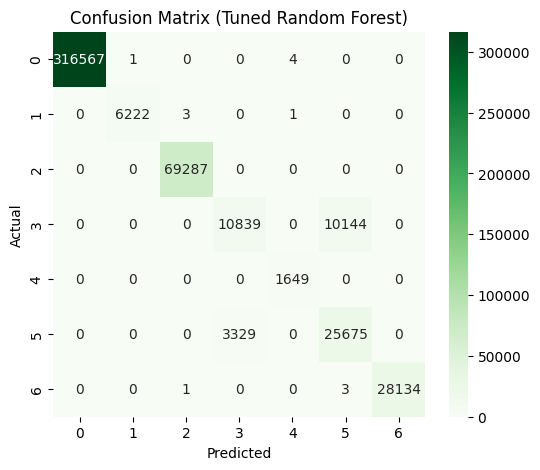

In [62]:
cm_rf = confusion_matrix(y_test, y_test_pred_rf)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.show()

In [63]:
rf_oof_probs = cross_val_predict(
    rf_final,
    X_train_rf,
    y_train,
    cv=3,
    method='predict_proba',
    n_jobs=-1
)

X_train_xgb = np.column_stack((X_train_rf, rf_oof_probs))

In [64]:
print(f"Old X_train shape: {X_train.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_train_xgb.shape}")

Old X_train shape: (2202006, 78)
New X_train_rf shape (with LR prob feature): (2202006, 92)


In [65]:
rf_test_probs = rf_final.predict_proba(X_test_rf)
X_test_xgb = np.column_stack((X_test_rf, rf_test_probs))

In [66]:
print(f"Old X_train shape: {X_test.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_test_xgb.shape}")

Old X_train shape: (471859, 78)
New X_train_rf shape (with LR prob feature): (471859, 92)


In [67]:
rf_val_probs = rf_final.predict_proba(X_val_rf)

X_val_xgb = np.column_stack((X_val_rf, rf_val_probs))

In [68]:
print(f"Old X_train shape: {X_val.shape}")
print(f"New X_train_rf shape (with LR prob feature): {X_val_xgb.shape}")

Old X_train shape: (471859, 78)
New X_train_rf shape (with LR prob feature): (471859, 92)


In [69]:
def objective_xgb(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 150, step=50),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 1),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 5),

        # Important for multiclass
        "objective": "multi:softprob",
        "num_class": len(set(y_train)),
        "eval_metric": "mlogloss",

        "random_state": 42,
        "n_jobs": -1
    }

    xgb_tune = XGBClassifier(**params)

    xgb_tune.fit(X_train_xgb, y_train)

    y_val_pred_xgb = xgb_tune.predict(X_val_xgb)

    return f1_score(y_val, y_val_pred_xgb, average="macro") 

In [70]:
study_xgb = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner()
)

[I 2026-04-10 22:46:46,764] A new study created in memory with name: no-name-3ecb0c60-9eaa-44ef-981f-886a6aabc98b


In [71]:
study_xgb.optimize(objective_xgb, n_trials=20, show_progress_bar=True)

  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-10 22:50:04,050] Trial 0 finished with value: 0.9133301869564844 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.03254723683608489, 'subsample': 0.728881285165978, 'colsample_bytree': 0.7801078409035422, 'reg_alpha': 0.015955809487350314, 'reg_lambda': 1.930209740346264}. Best is trial 0 with value: 0.9133301869564844.
[I 2026-04-10 22:56:30,649] Trial 1 finished with value: 0.9144432560254993 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1582123847467722, 'subsample': 0.7033438519337336, 'colsample_bytree': 0.8755533410031369, 'reg_alpha': 0.8918217193418586, 'reg_lambda': 3.2392435621053983}. Best is trial 1 with value: 0.9144432560254993.
[I 2026-04-10 22:57:45,961] Trial 2 finished with value: 0.9136287071411928 and parameters: {'n_estimators': 50, 'max_depth': 9, 'learning_rate': 0.029699259038812046, 'subsample': 0.6397186806649159, 'colsample_bytree': 0.9862648402098769, 'reg_alpha': 0.6900465950454746, 'reg_lambda':

In [72]:
print(f"\nBest XGB F1 Score: {study_xgb.best_trial.value:.4f}")
print(f"Best XGB Parameters: {study_xgb.best_trial.params}")

best_xgb_params = study_xgb.best_trial.params


Best XGB F1 Score: 0.9151
Best XGB Parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.1958072505191405, 'subsample': 0.841012326843089, 'colsample_bytree': 0.8880544120158315, 'reg_alpha': 0.798830340223422, 'reg_lambda': 3.6801901034500655}


In [73]:
xgb_final = XGBClassifier(
    **best_xgb_params,
    objective="multi:softprob",   
    num_class=len(set(y_train)),  
    eval_metric="mlogloss",       
    random_state=42,
    n_jobs=-1
)

In [74]:
xgb_final.fit(X_train_xgb, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8880544120158315, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='mlogloss', feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1958072505191405,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1, num_class=7, ...)

In [75]:
y_val_xgb_pred = xgb_final.predict(X_val_xgb)

print("Accuracy:", accuracy_score(y_val, y_val_xgb_pred))
print("F1 Score (Weighted):", f1_score(y_val, y_val_xgb_pred, average="weighted"))
print("F1 Score (Macro):", f1_score(y_val, y_val_xgb_pred, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_val, y_val_xgb_pred))

Accuracy: 0.9715020800705295
F1 Score (Weighted): 0.9700836365994475
F1 Score (Macro): 0.9150847501175325

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    316571
           1       1.00      1.00      1.00      6226
           2       1.00      1.00      1.00     69287
           3       0.78      0.50      0.61     20984
           4       1.00      1.00      1.00      1648
           5       0.71      0.89      0.79     29004
           6       1.00      1.00      1.00     28139

    accuracy                           0.97    471859
   macro avg       0.93      0.91      0.92    471859
weighted avg       0.97      0.97      0.97    471859



In [76]:
y_test_pred_xgb = xgb_final.predict(X_test_xgb)

In [77]:
y_prob_xgb = xgb_final.predict_proba(X_test_xgb)

In [78]:

print("\n--- Evaluation: XGB in test data ---")

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_xgb):.4f}")

# Correct F1
print(f"F1 Score (Weighted): {f1_score(y_test, y_test_pred_xgb, average='weighted'):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_test_pred_xgb, average='macro'):.4f}")

# Correct ROC-AUC (multiclass)
print(f"ROC-AUC (OvR): {roc_auc_score(y_test, y_prob_xgb, multi_class='ovr'):.4f}")

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_test_pred_xgb))


--- Evaluation: XGB in test data ---
Accuracy: 0.9713
F1 Score (Weighted): 0.9698
F1 Score (Macro): 0.9142
ROC-AUC (OvR): 0.9967

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    316572
           1       1.00      1.00      1.00      6226
           2       1.00      1.00      1.00     69287
           3       0.77      0.50      0.61     20983
           4       1.00      1.00      1.00      1649
           5       0.71      0.89      0.79     29004
           6       1.00      1.00      1.00     28138

    accuracy                           0.97    471859
   macro avg       0.93      0.91      0.91    471859
weighted avg       0.97      0.97      0.97    471859



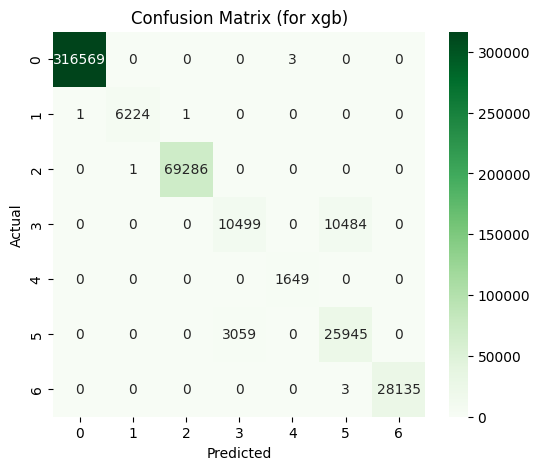

In [79]:
cm_rf = confusion_matrix(y_test, y_test_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (for xgb)")
plt.show()

In [83]:
lr_probs = final_model.predict_proba(X_test)
rf_probs = rf_final.predict_proba(X_test_rf)
xgb_probs = xgb_final.predict_proba(X_test_xgb)

lr_preds = final_model.predict(X_test)
rf_preds = rf_final.predict(X_test_rf)
xgb_preds = xgb_final.predict(X_test_xgb)

all_results_df = pd.DataFrame({
    'Actual_Label': y_test,
    'LR_Prediction': lr_preds,
    'RF_Prediction': rf_preds,
    'XGB_Prediction': xgb_preds
})

# Add LR probabilities
for i in range(lr_probs.shape[1]):
    all_results_df[f'LR_prob_class_{i}'] = lr_probs[:, i]

# Add RF probabilities
for i in range(rf_probs.shape[1]):
    all_results_df[f'RF_prob_class_{i}'] = rf_probs[:, i]

# Add XGB probabilities
for i in range(xgb_probs.shape[1]):
    all_results_df[f'XGB_prob_class_{i}'] = xgb_probs[:, i]

In [84]:
file_name = 'all_models_predictions_multiclass.csv'
all_results_df.to_csv(file_name, index=False)